# Investigating the 0.999 — A Data Leak Hunt

In notebook 1 I fixed the obvious data problem (the `test/` folder was just a copy of
`train/`), rebuilt the split by writer id so train and test share no people, and the plain
CNN *still* scored ROC-AUC 0.999 on writers it had never seen.

That bothers me. Notebook 1 was supposed to be the weak baseline. Signature verification is a
hard biometric problem, so a model that just stacks two images and runs them through a small
CNN should not be getting 0.999 on unseen people. Either the task is trivially easy (it isn't),
or the model found a shortcut and is getting the right answer for the wrong reason.

This notebook is the investigation. No deep learning and no GPU here — just pandas and a couple
of tiny scikit-learn probes. The goal is to figure out what the model actually learned, prove
it, fix the data, and prove the fix works.

The punchline up front: the label can be predicted from the *questioned* image alone, without
ever looking at the reference signature. So the model never really learned to compare two
signatures. The fix is in here too.

## 1. Setup

I just need the path to `sign_data`, whether I'm running locally or on Colab after a
`git clone`.

In [ ]:
import os
import glob
import re
import hashlib
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score


def find_root():
    for candidate in ['sign_data', '../sign_data', 'Signature-forgery-verification/sign_data']:
        if os.path.isdir(candidate):
            return candidate
    raise FileNotFoundError('sign_data not found - on Colab, git clone the repo first')

DATA_ROOT = find_root()
IMG_DIR   = os.path.join(DATA_ROOT, 'train')
print('dataset root:', DATA_ROOT)

dataset root: sign_data


## 2. Rebuilding the Pair Table

First I recreate the exact pair table notebook 1 trained on: combine both CSVs, drop the
duplicate rows, and pull the writer id out of the path. The columns are `(img1, img2, label)`,
where `img1` is the reference signature and `img2` is the questioned one. Label 0 means a match
(genuine), label 1 means a non-match (forgery).

In [ ]:
cols = ['img1', 'img2', 'label']
df = pd.concat([
    pd.read_csv(os.path.join(DATA_ROOT, 'train_data.csv'), header=None, names=cols),
    pd.read_csv(os.path.join(DATA_ROOT, 'test_data.csv'),  header=None, names=cols),
])
df = df.drop_duplicates().reset_index(drop=True)
df['writer'] = df['img1'].str.split('/').str[0].astype(int)

print('total unique pairs:', len(df))
print(df['label'].value_counts().rename({0: 'label 0 (match)', 1: 'label 1 (forgery)'}))
df.head()

total unique pairs: 23206
label
label 0 (match)      12602
label 1 (forgery)    10604
Name: count, dtype: int64


             img1                     img2  label  writer
0  068/09_068.png  068_forg/03_0113068.PNG      1      68
1  068/09_068.png  068_forg/01_0124068.PNG      1      68
2  068/09_068.png  068_forg/02_0124068.PNG      1      68
3  068/09_068.png  068_forg/01_0113068.PNG      1      68
4  068/09_068.png  068_forg/04_0124068.PNG      1      68

## 3. Where Does the Questioned Image Come From?

Before training any probe, I just want to look at the data. A genuine signature lives in a
folder like `049/` and a forgery in `049_forg/`. So a blunt question: is the label simply a
function of which folder `img2` sits in?

In [ ]:
df['img2_is_forg'] = df['img2'].str.split('/').str[0].str.contains('forg').astype(int)
df['img1_is_forg'] = df['img1'].str.split('/').str[0].str.contains('forg').astype(int)

print('does img1 ever come from a _forg folder?', bool(df['img1_is_forg'].any()))
print()
print('crosstab - rows = label, cols = img2 is in a _forg folder:')
print(pd.crosstab(df['label'], df['img2_is_forg']))

does img1 ever come from a _forg folder? False

crosstab - rows = label, cols = img2 is in a _forg folder:
img2_is_forg      0      1
label                     
0             12602      0
1                 0  10604


That table is perfectly diagonal:

- every label 0 (match) pair has a genuine `img2`
- every label 1 (forgery) pair has a forged `img2`
- `img1` is never a forgery — it is always a genuine reference

So `label == 1` exactly when `img2` is in a `_forg` folder, with no exceptions. The answer is
literally written on the folder name. A model doesn't need to compare the two signatures at
all; it just needs to tell whether `img2` looks forged.

## 4. Proving the Model Uses the Shortcut

A crosstab shows the leak *exists*. To show the model actually *relies* on it, I train two
deliberately crippled probes on the unseen writers (049+). Each is a small gradient-boosted
classifier on raw downscaled pixels — nothing fancy:

- **img1 only** sees only the reference signature. Since `img1` is always genuine it carries no
  information about the label, so this should score about 0.5 (chance).
- **img2 only** sees only the questioned signature. If the shortcut is real, this alone should
  score high, even though it never sees what it is being compared against.

Neither probe is ever shown both images, so neither one can actually compare anything.

In [ ]:
def sample_balanced(frame, n, seed=42):
    n_each = n // 2
    g = frame[frame.label == 0].sample(min(n_each, (frame.label == 0).sum()), random_state=seed)
    f = frame[frame.label == 1].sample(min(n_each, (frame.label == 1).sum()), random_state=seed)
    return pd.concat([g, f]).sample(frac=1, random_state=seed)


# writer-independent split, same protocol as the real notebooks
train_df = df[df.writer <= 40]
test_df  = df[df.writer >= 49]


def load_single(frame, col, H=60, W=90):
    X, y = [], []
    for _, row in frame.iterrows():
        im = cv2.imread(os.path.join(IMG_DIR, row[col]), cv2.IMREAD_GRAYSCALE)
        if im is None:
            continue
        im = cv2.resize(im, (W, H))
        # plt.imshow(im, cmap='gray'); plt.show()    # was eyeballing a few of these
        X.append(im.astype('float32').ravel() / 255.0)
        y.append(row['label'])
    return np.array(X), np.array(y)

In [ ]:
tr = sample_balanced(train_df, 3000)
te = sample_balanced(test_df,  2000)

results = {}
for col in ['img1', 'img2']:
    Xtr, ytr = load_single(tr, col)
    Xte, yte = load_single(te, col)
    clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:, 1]
    results[col] = roc_auc_score(yte, prob)
    print(f'{col}-only  ->  AUC on unseen writers: {results[col]:.3f}')

print()
print('img1 (reference) alone :', round(results['img1'], 3), '  <- ~0.5 = chance, as expected')
print('img2 (questioned) alone:', round(results['img2'], 3), '  <- high WITHOUT ever seeing the reference')

img1-only  ->  AUC on unseen writers: 0.493
img2-only  ->  AUC on unseen writers: 0.913

img1 (reference) alone : 0.493   <- ~0.5 = chance, as expected
img2 (questioned) alone: 0.913   <- high WITHOUT ever seeing the reference


That is the proof. A model that never sees the reference signature still separates genuine
from forged on people it never trained on. The reference image is dead weight; the questioned
image leaks the answer on its own. Notebook 1's CNN is just a stronger version of this
img2-only probe, which is how it pushed the number all the way to 0.999.

Why does the shortcut survive the writer-independent split? Because forgery artifacts —
hesitation, pen-lifts, the forger's own hand habits — are generic across people. "Looks forged"
transfers to new writers, so splitting by writer (which correctly stops the model memorizing
specific people) does nothing against this particular leak.

## 5. The Fix — Make the Questioned Image Useless on Its Own

The leak is really about how the pairs were built. There are only two recipes in the CSV:

| recipe | img1 | img2 | label |
|---|---|---|---|
| match    | genuine of A | genuine of A | 0 |
| forgery  | genuine of A | forgery of A | 1 |

Every genuine `img2` is a match and every forged `img2` is a non-match, so "is `img2` genuine?"
is the same question as "is it a match?". I break that by adding a third recipe: two genuine
signatures from *different* writers. That is a non-match (label 1) where `img2` is still genuine.

| recipe | img1 | img2 | label | what it teaches |
|---|---|---|---|---|
| match            | genuine of A | genuine of A          | 0 | same hand → same |
| hard negative    | genuine of A | forgery of A          | 1 | a skilled fake is still not A |
| random negative (new) | genuine of A | genuine of B   | 1 | a different person → different |

Now a genuine `img2` can be either label, so "is `img2` genuine?" tells you nothing. The only
way to get the label right is to actually compare `img1` against `img2`. These pairs don't exist
in the CSV, so I generate them from the raw per-writer folders.

In [ ]:
# index the folders: genuine[w] = w's genuine files, forg[w] = w's forgeries
genuine = {}
forg = {}
for d in sorted(os.listdir(IMG_DIR)):
    full = os.path.join(IMG_DIR, d)
    if not os.path.isdir(full):
        continue
    files = [os.path.join(d, f) for f in os.listdir(full) if f.lower().endswith(('.png', '.jpg'))]
    if d.endswith('_forg'):
        forg[int(d.replace('_forg', ''))] = files
    else:
        genuine[int(d)] = files

writers = sorted(set(genuine) & set(forg))
print('writers with both a genuine and a forgery folder:', len(writers))


def make_pairs(wset, per_writer, seed=42):
    rng = random.Random(seed)
    wlist = sorted(wset)
    rows = []
    for w in wlist:
        g = genuine.get(w, [])
        if len(g) < 2:
            continue
        for _ in range(per_writer):                  # match
            a, b = rng.sample(g, 2)
            rows.append((a, b, 0))
        for _ in range(per_writer // 2):             # hard negative: forgery of w
            if forg.get(w):
                rows.append((rng.choice(g), rng.choice(forg[w]), 1))
        for _ in range(per_writer // 2):             # random negative: a different writer
            other = rng.choice([x for x in wlist if x != w])
            rows.append((rng.choice(g), rng.choice(genuine[other]), 1))
    rng.shuffle(rows)
    return pd.DataFrame(rows, columns=['img1', 'img2', 'label'])


train_writers = [w for w in writers if w <= 40]
test_writers  = [w for w in writers if w >= 49]
fixed_tr = make_pairs(train_writers, per_writer=80)
fixed_te = make_pairs(test_writers,  per_writer=80)

print('fixed train pairs:', len(fixed_tr), '| balance:', dict(fixed_tr.label.value_counts()))
print('fixed test  pairs:', len(fixed_te), '| balance:', dict(fixed_te.label.value_counts()))

writers with both a genuine and a forgery folder: 64
fixed train pairs: 5600 | balance: {0: 2800, 1: 2800}
fixed test  pairs: 3360 | balance: {0: 1680, 1: 1680}


## 6. Does the Fix Actually Kill the Shortcut?

I check two things, because the answer is a bit more interesting than a single number.

First, the full rebuilt pairs with an img2-only probe. This won't drop all the way to 0.5, and
that's fine — half of my non-matches are still forgeries, and a forged `img2` is still always a
non-match, so a forgery detector remains a *partial* signal. The point is that it is no longer
*sufficient*: it can't tell a match from a different-writer non-match, because both have a
genuine `img2`.

Second, the clean test — genuine questioned images only. I throw away the forgery non-matches
and keep only pairs where `img2` is genuine. Now label 0 means same writer and label 1 means
different writer, and both have a genuine `img2`. If the img2-only probe scores about 0.5 here,
the questioned image carries no match/non-match information on its own, and the model is forced
to compare it against the reference. That is the real proof.

In [ ]:
def load_single_df(frame, col, H=60, W=90):
    X, y = [], []
    for _, row in frame.iterrows():
        im = cv2.imread(os.path.join(IMG_DIR, row[col]), cv2.IMREAD_GRAYSCALE)
        if im is None:
            continue
        X.append(cv2.resize(im, (W, H)).astype('float32').ravel() / 255.0)
        y.append(row['label'])
    return np.array(X), np.array(y)


# (a) full rebuilt pairs, img2 only
Xtr, ytr = load_single_df(fixed_tr, 'img2')
Xte, yte = load_single_df(fixed_te, 'img2')
clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
auc_full = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])

# (b) genuine-img2 subset only: match (same writer) vs non-match (different writer)
gen_tr = fixed_tr[~fixed_tr.img2.str.contains('_forg')]
gen_te = fixed_te[~fixed_te.img2.str.contains('_forg')]
Xtr, ytr = load_single_df(gen_tr, 'img2')
Xte, yte = load_single_df(gen_te, 'img2')
clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
auc_gen = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])

print('ORIGINAL leaky pairs, img2-only               :', round(results['img2'], 3))
print('REBUILT pairs,        img2-only (all)         :', round(auc_full, 3), '  <- forgery signal remains, but not enough')
print('REBUILT pairs,        img2-only (genuine only):', round(auc_gen, 3), '  <- ~0.5: match vs non-match no longer leaked')

ORIGINAL leaky pairs, img2-only               : 0.913
REBUILT pairs,        img2-only (all)         : 0.694   <- forgery signal remains, but not enough
REBUILT pairs,        img2-only (genuine only): 0.524   <- ~0.5: match vs non-match no longer leaked


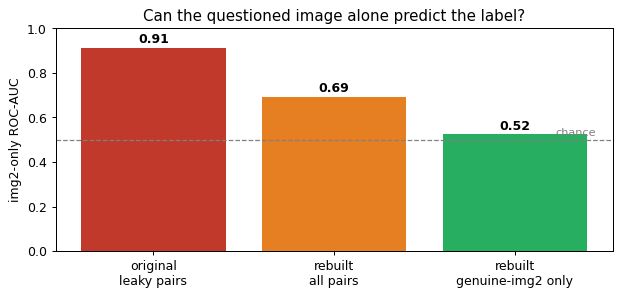

In [ ]:
# a small bar chart worth keeping
fig, ax = plt.subplots(figsize=(7, 3.4))
labels = ['original\nleaky pairs', 'rebuilt\nall pairs', 'rebuilt\ngenuine-img2 only']
vals   = [results['img2'], auc_full, auc_gen]
bars = ax.bar(labels, vals, color=['#c0392b', '#e67e22', '#27ae60'])
ax.axhline(0.5, ls='--', c='gray', lw=1)
ax.text(2.45, 0.52, 'chance', color='gray', ha='right', fontsize=9)
ax.set_ylabel('img2-only ROC-AUC')
ax.set_ylim(0, 1)
ax.set_title('Can the questioned image alone predict the label?')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. A Cleaner Dataset on the Side — the NFI Set

There is a second signature set in the repo, `sign_data_nfi` (a deduplicated, resized subset of
the NFI `sample_Signature` collection). Its filenames encode who signed and whose signature it
is meant to be — `NFI-XXXYYZZZ`, genuine when `XXX == ZZZ`. The forgeries here are *targeted*:
someone deliberately imitating a specific person.

Does the img2-only shortcut work on this one too? I build the classic genuine-vs-forgery pairs
(the leaky recipe) and probe.

In [ ]:
NFI_DIR = None
for candidate in ['sign_data_nfi', '../sign_data_nfi', 'Signature-forgery-verification/sign_data_nfi']:
    if os.path.isdir(candidate):
        NFI_DIR = candidate
        break

if NFI_DIR is None:
    print('sign_data_nfi not found - skipping (clone the repo to run this section)')
else:
    def parse_owner(fn):
        s = re.sub(r'^NFI-', '', os.path.basename(fn))
        s = os.path.splitext(s)[0]
        if re.fullmatch(r'\d{8}', s):
            return s[5:8]
        return None

    g_by_owner = {}
    f_by_owner = {}
    for f in glob.glob(os.path.join(NFI_DIR, 'genuine', '*')):
        owner = parse_owner(f)
        if owner:
            g_by_owner.setdefault(owner, []).append(f)
    for f in glob.glob(os.path.join(NFI_DIR, 'forged', '*')):
        owner = parse_owner(f)
        if owner:
            f_by_owner.setdefault(owner, []).append(f)

    owners = sorted(set(g_by_owner) & set(f_by_owner), key=int)
    train_owners = owners[:18]
    test_owners  = owners[18:]
    print('NFI owners:', len(owners), '| train', len(train_owners), '| test', len(test_owners))

    def nfi_img2_probe(owner_set):
        rows = []
        for o in owner_set:
            for x in g_by_owner[o][1:]:        # genuine img2 (match)
                rows.append((x, 0))
            for x in f_by_owner.get(o, []):    # forged img2 (non-match)
                rows.append((x, 1))
        X = np.array([cv2.resize(cv2.imread(fn, cv2.IMREAD_GRAYSCALE), (90, 60)).astype('float32').ravel() / 255.0
                      for fn, _ in rows])
        y = np.array([lbl for _, lbl in rows])
        return X, y

    Xtr, ytr = nfi_img2_probe(train_owners)
    Xte, yte = nfi_img2_probe(test_owners)
    clf = HistGradientBoostingClassifier(max_iter=200, random_state=42).fit(Xtr, ytr)
    auc_nfi = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])
    print('img2-only AUC on NFI (leaky recipe!):', round(auc_nfi, 3), '  <- ~0.5 even with genuine-vs-forgery pairs')

NFI owners: 30 | train 18 | test 12
img2-only AUC on NFI (leaky recipe!): 0.584   <- ~0.5 even with genuine-vs-forgery pairs


The same leaky recipe that scored about 0.9 on `sign_data` scores roughly chance here.
Because the NFI forgeries are targeted imitations, "looks forged" is no longer a giveaway — a
good forgery is supposed to look genuine. That makes `sign_data_nfi` an honest, independent
cross-dataset test set for the later notebooks, even though it is small (30 writers).

## 8. What I Learned, and What Changes Downstream

**The bug.** Notebook 1's 0.999 was a label leak, not skill. The way the pairs were built made
the label a deterministic function of the questioned image's folder, so the model learned a
generic forgery detector and ignored the reference completely. The writer-independent split
didn't catch it because forgery artifacts generalize across people.

**The lesson.** A suspiciously good number from a model that *shouldn't* be that good is a
reason to go and check the data, not to celebrate. The cheapest possible probe — predicting the
label from one image with a tree model — exposed it in seconds, no GPU required.

**The fix.** Add genuine-vs-different-writer negatives so a genuine `img2` no longer implies
"match". A forged `img2` is still always a non-match, so a forgery detector stays a partial
signal, but it is no longer sufficient: on the genuine-only subset the img2-only probe falls to
about 0.5, so the model is forced to compare the two signatures.

**Downstream (notebook 2 onward).** Those notebooks build pairs the same way, so the `make_pairs`
function here is the template they should use. And `sign_data_nfi` gives me a clean second source
for cross-dataset numbers, which is the most honest evaluation this project can show.

Notebook 1 stays exactly as it is — the naive baseline whose too-good score is the whole reason
this investigation happened.